# Racing Telemetry — SQL Analysis

This notebook demonstrates SQL-based analysis of the racing telemetry dataset using two complementary tools:

| Tool | Role | Input |
|---|---|---|
| **SQLite** | Relational DB, classic SQL, aggregations | CSV loaded into `.db` file |
| **DuckDB** | Analytical SQL, window functions, OLAP | `features_engineered.parquet` directly |

## Query Categories
1. Lap performance summary
2. Track section time distribution
3. Corner ranking & difficulty
4. Safety events (wheel spin, wheel lock)
5. Tire temperature & fuel consumption
6. Advanced analytics with window functions

## 1. Setup

In [1]:
import sqlite3
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor': '#0f0f0f', 'axes.facecolor': '#1a1a1a',
    'axes.edgecolor': '#444444', 'axes.labelcolor': '#cccccc',
    'xtick.color': '#888888', 'ytick.color': '#888888',
    'text.color': '#cccccc', 'grid.color': '#2a2a2a',
    'grid.linewidth': 0.6, 'axes.titlesize': 12,
    'legend.facecolor': '#1a1a1a', 'legend.edgecolor': '#444444',
    'figure.dpi': 110,
})

LAP_COLORS = {1: '#00d4ff', 2: '#ff6b35', 3: '#7fff00', 4: '#ff00aa'}
PARQUET_PATH = 'features_engineered.parquet'
CSV_PATH     = 'telemetry-rio-5-laps.csv'
DB_PATH      = 'telemetry.db'

print(f'DuckDB  : {duckdb.__version__}')
print(f'SQLite  : {sqlite3.sqlite_version}')
print(f'pandas  : {pd.__version__}')

DuckDB  : 1.5.3
SQLite  : 3.50.4
pandas  : 3.0.2


---
# Part A — SQLite

SQLite stores the data in a local file (`telemetry.db`). Perfect for relational queries, joins between tables, and sharing a self-contained database.

## 2. Build the SQLite Database

In [2]:
# Load engineered features (parquet → DataFrame → SQLite)
df = pd.read_parquet(PARQUET_PATH)

conn = sqlite3.connect(DB_PATH)

# Main telemetry table
df.to_sql('telemetry', conn, if_exists='replace', index=False)

# Corner catalog table (from feature engineering output)
df_corners = pd.read_csv('features_per_corner.csv')
df_corners.to_sql('corners', conn, if_exists='replace', index=False)

# Lap summary table
df_laps = pd.read_csv('features_per_lap.csv')
df_laps.to_sql('lap_summary', conn, if_exists='replace', index=False)

print('SQLite tables created:')
for row in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall():
    count = conn.execute(f"SELECT COUNT(*) FROM {row[0]}").fetchone()[0]
    print(f'  {row[0]:<20} {count:>7,} rows')

SQLite tables created:
  telemetry             75,090 rows
  corners                   56 rows
  lap_summary                4 rows


## 3. [SQLite] Lap Performance Summary

In [3]:
query = """
SELECT
    lap_number,
    ROUND(MAX(current_lap_time), 3)          AS lap_time_s,
    ROUND(AVG(speed_kmh), 1)                 AS avg_speed_kmh,
    ROUND(MAX(speed_kmh), 1)                 AS max_speed_kmh,
    ROUND(MIN(speed_kmh), 1)                 AS min_speed_kmh,
    ROUND(AVG(throttle_norm) * 100, 1)       AS avg_throttle_pct,
    ROUND(SUM(CASE WHEN throttle_norm > 0.95 THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)               AS pct_full_throttle,
    ROUND(SUM(CASE WHEN brake_norm > 0.10 THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 1)               AS pct_braking,
    ROUND((MAX(fuel) - MIN(fuel)) * 100, 3)  AS fuel_consumed_pct
FROM telemetry
GROUP BY lap_number
ORDER BY lap_number
"""

df_lap_perf = pd.read_sql_query(query, conn)
df_lap_perf['best_lap'] = df_lap_perf['lap_time_s'] == df_lap_perf['lap_time_s'].min()
print(df_lap_perf.to_string(index=False))

 lap_number  lap_time_s  avg_speed_kmh  max_speed_kmh  min_speed_kmh  avg_throttle_pct  pct_full_throttle  pct_braking  fuel_consumed_pct  best_lap
          1     158.154          138.7          220.6           36.2              66.9               48.5         16.3              7.203     False
          2     155.698          140.9          223.8           57.8              65.6               44.1         14.8              6.908     False
          3     158.830          138.5          224.9           43.4              71.4               54.2         15.8              7.488     False
          4     153.113          143.3          219.1           58.4              68.4               51.3         15.9              7.319      True


## 4. [SQLite] Track Section Distribution

In [4]:
query = """
SELECT
    track_section,
    COUNT(*)                                         AS samples,
    ROUND(COUNT(*) * 100.0 / SUM(COUNT(*)) OVER (), 1) AS pct_total,
    ROUND(AVG(speed_kmh), 1)                         AS avg_speed_kmh,
    ROUND(MAX(speed_kmh), 1)                         AS max_speed_kmh,
    ROUND(AVG(ABS(g_lateral)), 3)                    AS avg_abs_lat_g,
    ROUND(AVG(throttle_norm) * 100, 1)               AS avg_throttle_pct,
    ROUND(AVG(brake_norm) * 100, 1)                  AS avg_brake_pct
FROM telemetry
GROUP BY track_section
ORDER BY samples DESC
"""

df_sections = pd.read_sql_query(query, conn)
print(df_sections.to_string(index=False))

track_section  samples  pct_total  avg_speed_kmh  max_speed_kmh  avg_abs_lat_g  avg_throttle_pct  avg_brake_pct
       CORNER    35420       47.2          131.5          224.9          1.048              70.0            0.0
 ACCELERATION    26139       34.8          151.4          224.5          0.167              98.3            0.0
      BRAKING    11803       15.7          140.0          223.5          0.558               2.6           69.5
     STRAIGHT     1728        2.3          154.7          220.6          0.224              18.4            0.6


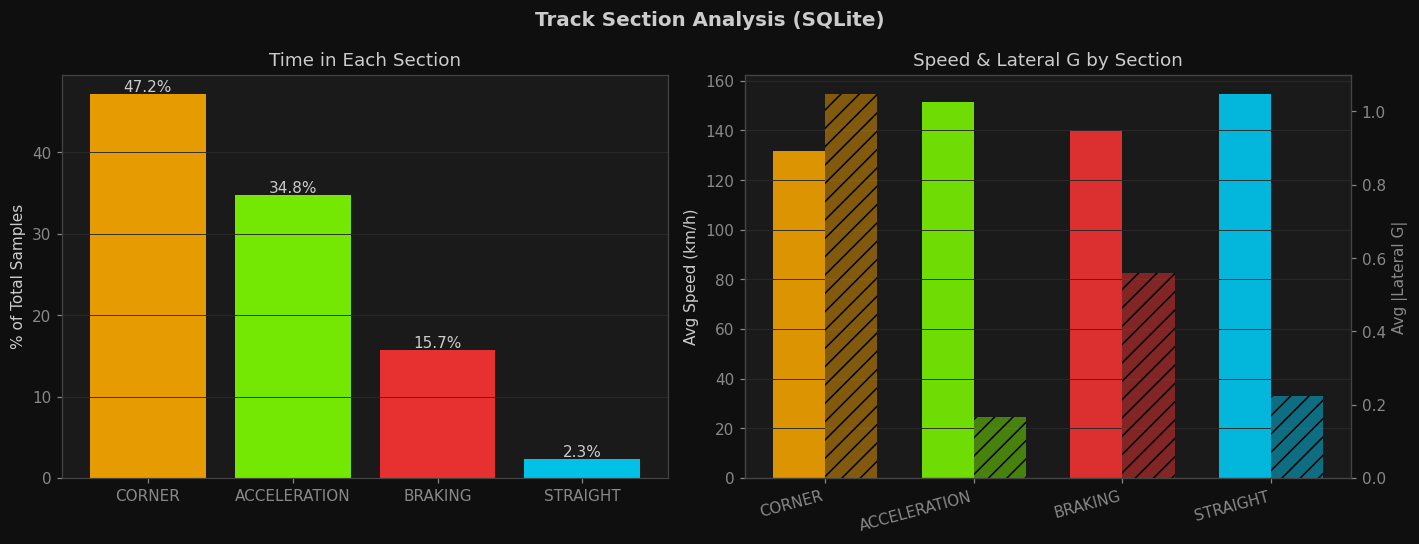

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Track Section Analysis (SQLite)', fontsize=13, fontweight='bold')

SECTION_COLORS = {
    'STRAIGHT': '#00d4ff', 'ACCELERATION': '#7fff00',
    'BRAKING':  '#ff3333', 'CORNER':       '#ffaa00',
}
bar_colors = [SECTION_COLORS.get(s, '#888888') for s in df_sections['track_section']]

ax = axes[0]
bars = ax.bar(df_sections['track_section'], df_sections['pct_total'],
              color=bar_colors, edgecolor='none', alpha=0.9)
for bar, val in zip(bars, df_sections['pct_total']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', fontsize=10)
ax.set_ylabel('% of Total Samples')
ax.set_title('Time in Each Section')
ax.grid(True, axis='y')

ax = axes[1]
x = np.arange(len(df_sections))
w = 0.35
b1 = ax.bar(x - w/2, df_sections['avg_speed_kmh'], w,
            color=bar_colors, alpha=0.85, label='Avg speed (km/h)')
ax2 = ax.twinx()
ax2.bar(x + w/2, df_sections['avg_abs_lat_g'], w,
        color=bar_colors, alpha=0.45, hatch='//', label='Avg |lat G|')
ax2.set_ylabel('Avg |Lateral G|', color='#888888')
ax2.tick_params(colors='#888888')
ax.set_xticks(x)
ax.set_xticklabels(df_sections['track_section'], rotation=15, ha='right')
ax.set_ylabel('Avg Speed (km/h)')
ax.set_title('Speed & Lateral G by Section')
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('sql_sections.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 5. [SQLite] Corner Ranking & Difficulty

In [6]:
query = """
SELECT
    corner_num,
    ROUND(AVG(dist_m), 0)             AS dist_m,
    ROUND(AVG(apex_speed_kmh), 1)     AS avg_apex_speed_kmh,
    ROUND(MIN(apex_speed_kmh), 1)     AS min_apex_speed_kmh,
    ROUND(MAX(apex_speed_kmh), 1)     AS max_apex_speed_kmh,
    ROUND(MAX(apex_speed_kmh)
          - MIN(apex_speed_kmh), 1)   AS apex_speed_range_kmh,
    ROUND(AVG(max_lat_g), 3)          AS avg_max_lat_g,
    ROUND(AVG(speed_loss_kmh), 1)     AS avg_speed_loss_kmh,
    ROUND(AVG(entry_speed_kmh), 1)    AS avg_entry_speed_kmh
FROM corners
GROUP BY corner_num
ORDER BY avg_apex_speed_kmh ASC
"""

df_corner_rank = pd.read_sql_query(query, conn)

# Difficulty score: high speed loss + high lateral G + low apex speed
df_corner_rank['difficulty_score'] = (
    (df_corner_rank['avg_speed_loss_kmh'] / df_corner_rank['avg_speed_loss_kmh'].max()) * 0.4 +
    (df_corner_rank['avg_max_lat_g']      / df_corner_rank['avg_max_lat_g'].max())      * 0.4 +
    (1 - df_corner_rank['avg_apex_speed_kmh'] / df_corner_rank['avg_apex_speed_kmh'].max()) * 0.2
).round(3)

df_corner_rank = df_corner_rank.sort_values('difficulty_score', ascending=False)
print('Corner difficulty ranking (hardest first):')
print(df_corner_rank[['corner_num','dist_m','avg_apex_speed_kmh',
                       'avg_speed_loss_kmh','avg_max_lat_g',
                       'apex_speed_range_kmh','difficulty_score']].to_string(index=False))

Corner difficulty ranking (hardest first):
 corner_num  dist_m  avg_apex_speed_kmh  avg_speed_loss_kmh  avg_max_lat_g  apex_speed_range_kmh  difficulty_score
          2   621.0               141.3                 8.6          1.319                  28.1             0.760
         14  5365.0                65.2                 5.7          1.441                  48.5             0.744
          7  2704.0               112.1                 5.7          1.623                  37.7             0.734
          8  3094.0               106.6                 5.9          1.503                  11.5             0.720
         12  4665.0                98.1                 4.6          1.473                  81.7             0.662
          6  2422.0                99.3                 4.5          1.466                  39.3             0.654
          3  1080.0                55.8                 3.9          1.322                  31.6             0.642
          5  2133.0               112

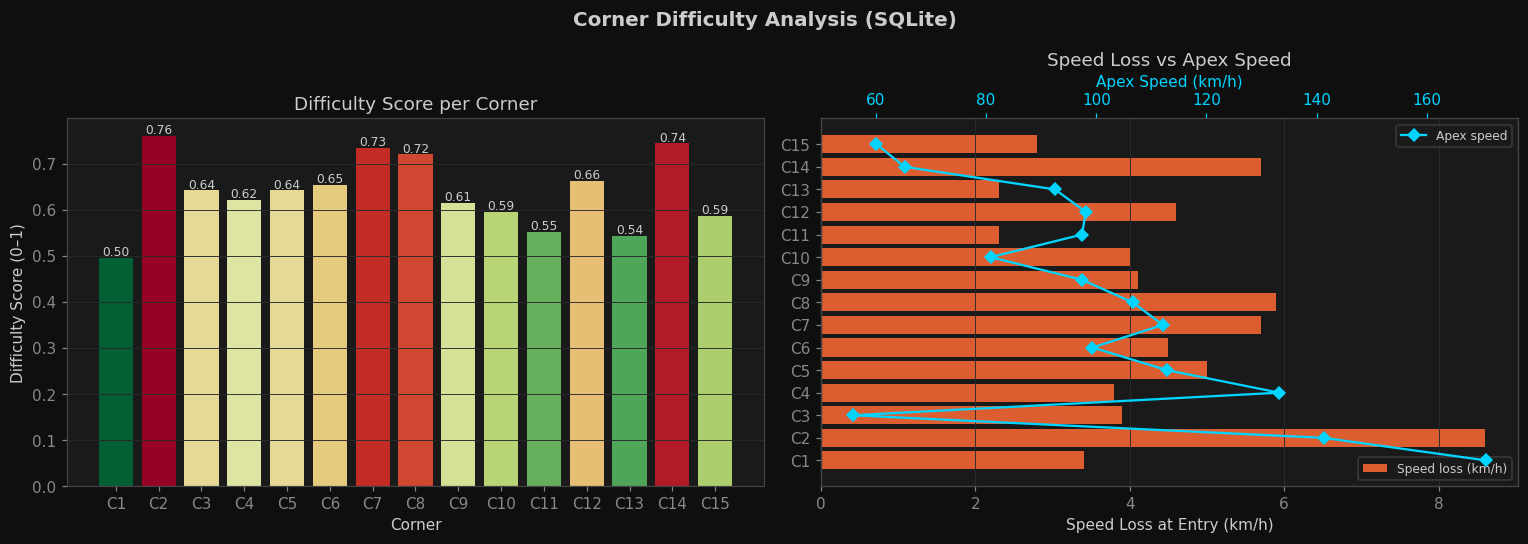

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Corner Difficulty Analysis (SQLite)', fontsize=13, fontweight='bold')

df_sorted = df_corner_rank.sort_values('corner_num')
corner_labels = [f'C{int(c)}' for c in df_sorted['corner_num']]

ax = axes[0]
diff_colors = plt.cm.RdYlGn_r(
    (df_sorted['difficulty_score'] - df_sorted['difficulty_score'].min()) /
    (df_sorted['difficulty_score'].max() - df_sorted['difficulty_score'].min())
)
bars = ax.bar(corner_labels, df_sorted['difficulty_score'],
              color=diff_colors, edgecolor='none', alpha=0.9)
for bar, val in zip(bars, df_sorted['difficulty_score']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.2f}', ha='center', fontsize=8)
ax.set_xlabel('Corner')
ax.set_ylabel('Difficulty Score (0–1)')
ax.set_title('Difficulty Score per Corner')
ax.grid(True, axis='y')

ax = axes[1]
ax.barh(corner_labels, df_sorted['avg_speed_loss_kmh'],
        color='#ff6b35', alpha=0.85, label='Speed loss (km/h)')
ax2 = ax.twiny()
ax2.plot(df_sorted['avg_apex_speed_kmh'], corner_labels,
         color='#00d4ff', marker='D', markersize=6, lw=1.5, label='Apex speed')
ax2.set_xlabel('Apex Speed (km/h)', color='#00d4ff')
ax2.tick_params(colors='#00d4ff')
ax.set_xlabel('Speed Loss at Entry (km/h)')
ax.set_title('Speed Loss vs Apex Speed')
ax.grid(True, axis='x')
ax.legend(loc='lower right', fontsize=8)
ax2.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig('sql_corner_ranking.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 6. [SQLite] Safety Events — Wheel Spin & Wheel Lock

In [8]:
query = """
SELECT
    lap_number,
    -- Wheel spin: rear faster than front by > 5%
    SUM(CASE WHEN wheel_spin_index > 0.05  THEN 1 ELSE 0 END) AS spin_events,
    ROUND(SUM(CASE WHEN wheel_spin_index > 0.05  THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 2)                                 AS spin_pct,
    -- Wheel lock: brake high + negative spin index
    SUM(wheel_lock_flag)                                       AS lock_events,
    ROUND(SUM(CAST(wheel_lock_flag AS FLOAT))
          / COUNT(*) * 100, 2)                                 AS lock_pct,
    -- Peak oversteer: rear slip > front slip significantly
    SUM(CASE WHEN understeer_index < -0.01 THEN 1 ELSE 0 END) AS oversteer_samples,
    ROUND(SUM(CASE WHEN understeer_index < -0.01 THEN 1.0 ELSE 0.0 END)
          / COUNT(*) * 100, 2)                                 AS oversteer_pct
FROM telemetry
GROUP BY lap_number
ORDER BY lap_number
"""

df_events = pd.read_sql_query(query, conn)
print(df_events.to_string(index=False))

 lap_number  spin_events  spin_pct  lock_events  lock_pct  oversteer_samples  oversteer_pct
          1         3453     18.19          811      4.27               4193          22.09
          2         2582     13.82          818      4.38               3843          20.57
          3         3796     19.92          814      4.27               4319          22.66
          4         3265     17.77          917      4.99               3406          18.54


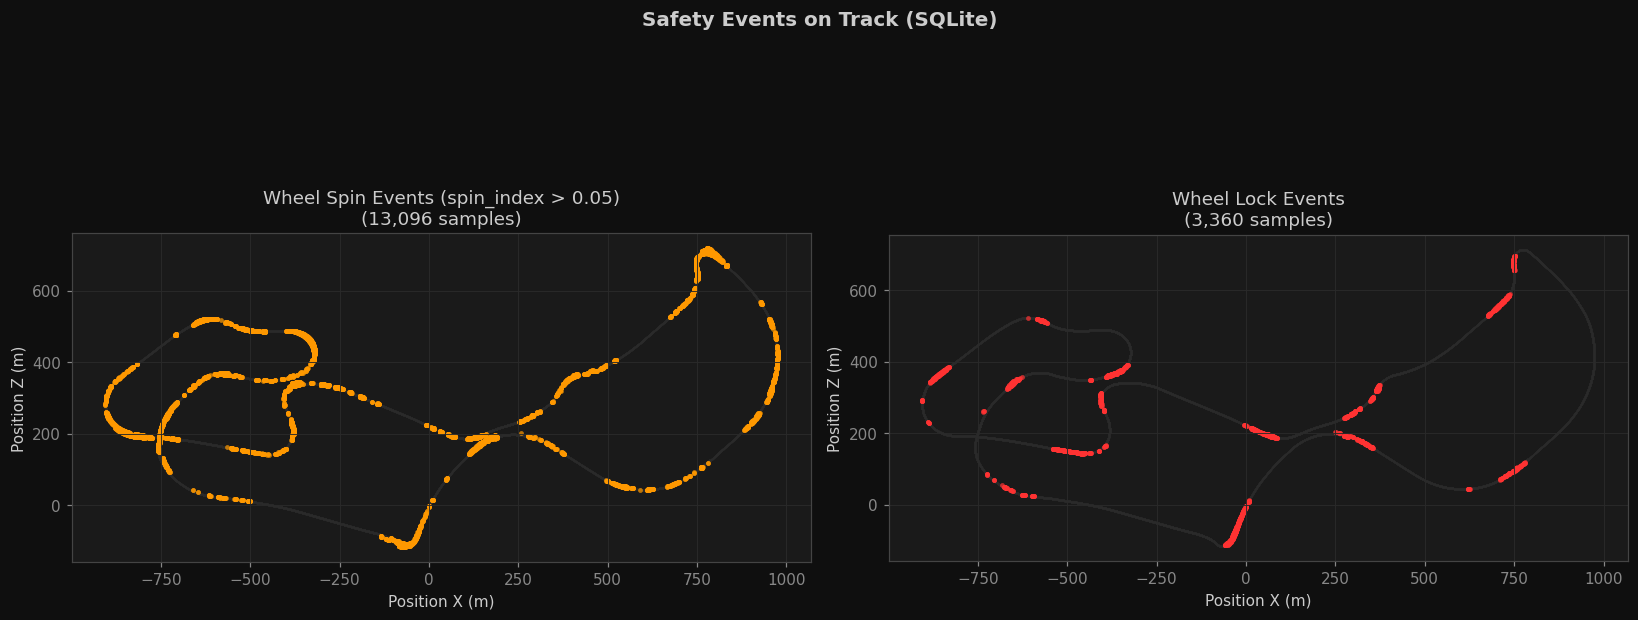

In [9]:
# Where on the track do spin events happen?
query_spin_map = """
SELECT
    lap_number,
    lap_dist_pct,
    position_x,
    position_z,
    wheel_spin_index,
    wheel_lock_flag
FROM telemetry
WHERE wheel_spin_index > 0.05 OR wheel_lock_flag = 1
"""
df_spin_map = pd.read_sql_query(query_spin_map, conn)

# Full track base (lap 1)
df_base = pd.read_sql_query(
    "SELECT position_x, position_z FROM telemetry WHERE lap_number = 1", conn
)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.suptitle('Safety Events on Track (SQLite)', fontsize=13, fontweight='bold')

for ax, event_col, color, title in [
    (axes[0], 'wheel_spin_index', '#ff9900', 'Wheel Spin Events (spin_index > 0.05)'),
    (axes[1], 'wheel_lock_flag',  '#ff3333', 'Wheel Lock Events'),
]:
    ax.scatter(df_base['position_x'], df_base['position_z'],
               s=1.5, color='#2a2a2a', linewidths=0)
    mask = (df_spin_map[event_col] > 0) if event_col == 'wheel_spin_index' \
           else (df_spin_map[event_col] == 1)
    ev = df_spin_map[mask]
    ax.scatter(ev['position_x'], ev['position_z'],
               s=10, color=color, alpha=0.7, linewidths=0)
    ax.set_title(f'{title}\n({len(ev):,} samples)')
    ax.set_xlabel('Position X (m)')
    ax.set_ylabel('Position Z (m)')
    ax.set_aspect('equal')
    ax.grid(True)

plt.tight_layout()
plt.savefig('sql_safety_events.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 7. [SQLite] Tire Temperature & Fuel Consumption

In [10]:
query = """
SELECT
    lap_number,
    ROUND(MIN(tire_temp_avg), 2)                      AS tire_temp_start_c,
    ROUND(MAX(tire_temp_avg), 2)                      AS tire_temp_peak_c,
    ROUND(AVG(tire_temp_avg), 2)                      AS tire_temp_avg_c,
    ROUND(MAX(tire_temp_avg) - MIN(tire_temp_avg), 3) AS tire_temp_rise_c,
    ROUND(AVG(tire_temp_fr_delta), 4)                 AS fr_imbalance_c,
    ROUND(AVG(tire_temp_lr_delta), 4)                 AS lr_imbalance_c,
    ROUND((MAX(fuel) - MIN(fuel)) * 100, 4)           AS fuel_consumed_pct,
    ROUND(AVG(combined_slip_avg), 5)                  AS avg_slip
FROM telemetry
GROUP BY lap_number
ORDER BY lap_number
"""

df_tire_fuel = pd.read_sql_query(query, conn)
print(df_tire_fuel.to_string(index=False))

 lap_number  tire_temp_start_c  tire_temp_peak_c  tire_temp_avg_c  tire_temp_rise_c  fr_imbalance_c  lr_imbalance_c  fuel_consumed_pct  avg_slip
          1             208.87            222.98           212.24            14.114          0.4778          0.1448             7.2031   0.50961
          2             208.67            224.72           212.18            16.047          0.7582          0.0652             6.9078   0.49428
          3             208.81            286.72           216.06            77.908         -1.1261         -0.1580             7.4882   0.63104
          4             208.52            224.55           212.72            16.030          1.2422          0.0878             7.3192   0.54532


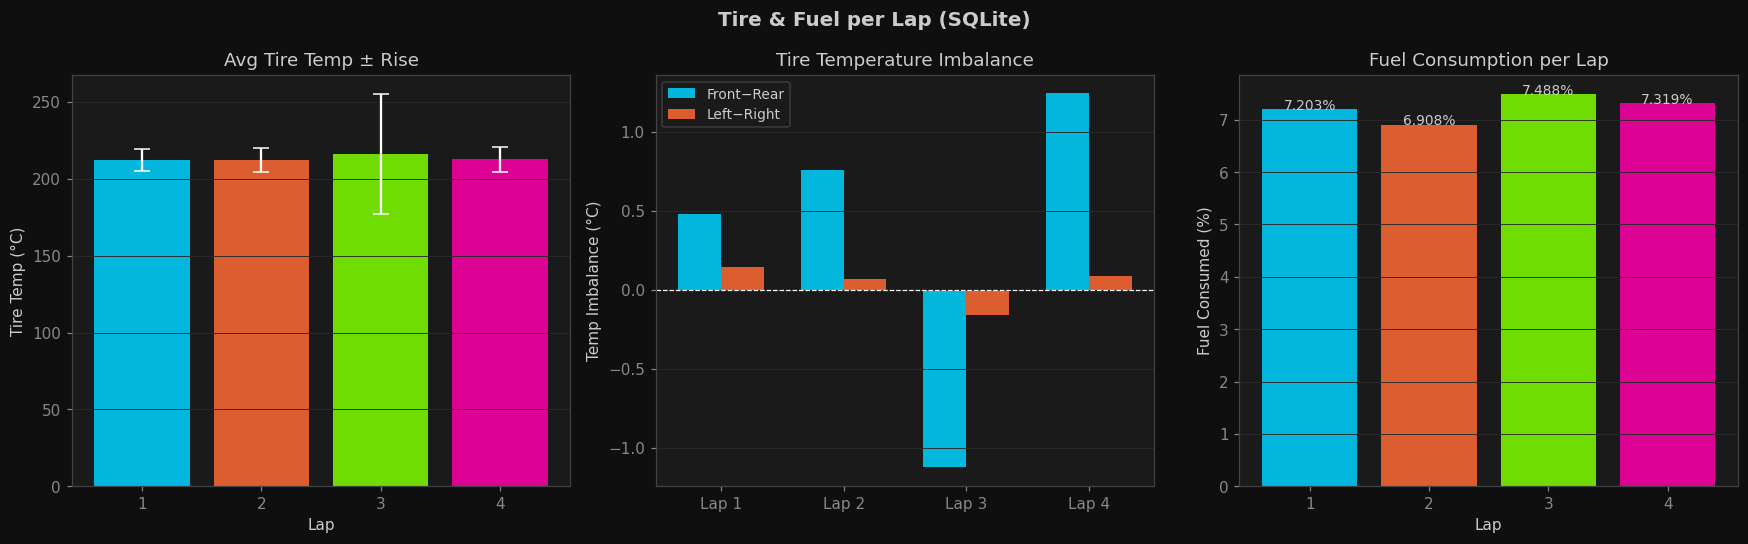

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Tire & Fuel per Lap (SQLite)', fontsize=13, fontweight='bold')

laps = df_tire_fuel['lap_number'].tolist()
colors = [LAP_COLORS[l] for l in laps]

ax = axes[0]
ax.bar(laps, df_tire_fuel['tire_temp_avg_c'], color=colors, alpha=0.85)
ax.errorbar(laps, df_tire_fuel['tire_temp_avg_c'],
            yerr=df_tire_fuel['tire_temp_rise_c'] / 2,
            fmt='none', color='white', capsize=5, lw=1.5)
ax.set_xlabel('Lap'); ax.set_ylabel('Tire Temp (°C)')
ax.set_title('Avg Tire Temp ± Rise')
ax.set_xticks(laps)
ax.grid(True, axis='y')

ax = axes[1]
x = np.arange(len(laps))
w = 0.35
ax.bar(x - w/2, df_tire_fuel['fr_imbalance_c'], w, color='#00d4ff',
       alpha=0.85, label='Front−Rear')
ax.bar(x + w/2, df_tire_fuel['lr_imbalance_c'], w, color='#ff6b35',
       alpha=0.85, label='Left−Right')
ax.axhline(0, color='white', lw=0.8, linestyle='--')
ax.set_xticks(x); ax.set_xticklabels([f'Lap {l}' for l in laps])
ax.set_ylabel('Temp Imbalance (°C)')
ax.set_title('Tire Temperature Imbalance')
ax.legend(fontsize=9); ax.grid(True, axis='y')

ax = axes[2]
bars = ax.bar(laps, df_tire_fuel['fuel_consumed_pct'],
              color=colors, alpha=0.85)
for bar, val in zip(bars, df_tire_fuel['fuel_consumed_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.3f}%', ha='center', fontsize=9)
ax.set_xlabel('Lap'); ax.set_ylabel('Fuel Consumed (%)')
ax.set_title('Fuel Consumption per Lap')
ax.set_xticks(laps); ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('sql_tire_fuel.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

---
# Part B — DuckDB

DuckDB reads the Parquet file directly — no ETL, no server. Designed for analytical (OLAP) queries with full SQL:2003 support including **window functions**.

## 8. Connect to DuckDB & Inspect the Parquet

In [12]:
duck = duckdb.connect()

# Register the parquet as a virtual table
duck.execute(f"CREATE VIEW telemetry AS SELECT * FROM read_parquet('{PARQUET_PATH}')")

schema = duck.execute("DESCRIBE telemetry").df()
print(f'Columns: {len(schema)}')
print(schema[['column_name', 'column_type']].to_string(index=False))

Columns: 42
                             column_name column_type
                              lap_number      BIGINT
                              lap_dist_m      DOUBLE
                            lap_dist_pct      DOUBLE
                        current_lap_time      DOUBLE
                       current_race_time      DOUBLE
                              position_x      DOUBLE
                              position_y      DOUBLE
                              position_z      DOUBLE
                           throttle_norm      DOUBLE
                              brake_norm      DOUBLE
                              steer_norm      DOUBLE
                                    gear      BIGINT
                               speed_kmh      DOUBLE
                       speed_delta_kmh_s      DOUBLE
                      current_engine_rpm      DOUBLE
                                power_kw      DOUBLE
                                  torque      DOUBLE
                                  

## 9. [DuckDB] Window Function — Lap Ranking & Running Stats

In [13]:
query = """
WITH lap_stats AS (
    SELECT
        lap_number,
        MAX(current_lap_time)          AS lap_time_s,
        AVG(speed_kmh)                 AS avg_speed_kmh,
        MAX(speed_kmh)                 AS max_speed_kmh,
        AVG(throttle_norm) * 100       AS avg_throttle_pct,
        MAX(fuel) - MIN(fuel)          AS fuel_delta
    FROM telemetry
    GROUP BY lap_number
)
SELECT
    lap_number,
    ROUND(lap_time_s, 3)                                     AS lap_time_s,
    RANK()    OVER (ORDER BY lap_time_s ASC)                 AS time_rank,
    ROUND(lap_time_s - MIN(lap_time_s) OVER (), 3)           AS gap_to_best_s,
    ROUND(avg_speed_kmh, 1)                                  AS avg_speed_kmh,
    ROUND(avg_throttle_pct, 1)                               AS avg_throttle_pct,
    ROUND(fuel_delta * 100, 4)                               AS fuel_consumed_pct,
    ROUND(AVG(lap_time_s) OVER () - lap_time_s, 3)          AS vs_avg_s
FROM lap_stats
ORDER BY lap_number
"""

df_duck_laps = duck.execute(query).df()
print(df_duck_laps.to_string(index=False))

 lap_number  lap_time_s  time_rank  gap_to_best_s  avg_speed_kmh  avg_throttle_pct  fuel_consumed_pct  vs_avg_s
          1     158.154          3          5.041          138.7              66.9             7.2031    -1.706
          2     155.698          2          2.584          140.9              65.6             6.9078     0.751
          3     158.830          4          5.717          138.5              71.4             7.4882    -2.381
          4     153.113          1          0.000          143.3              68.4             7.3192     3.336


## 10. [DuckDB] Window Function — Speed Delta with LAG/LEAD

In [14]:
query = """
SELECT
    lap_number,
    ROUND(lap_dist_pct, 2)                                              AS dist_pct,
    ROUND(speed_kmh, 1)                                                 AS speed_kmh,
    ROUND(LAG(speed_kmh, 12) OVER
          (PARTITION BY lap_number ORDER BY lap_dist_pct), 1)           AS speed_1s_ago,
    ROUND(speed_kmh - LAG(speed_kmh, 12)
          OVER (PARTITION BY lap_number ORDER BY lap_dist_pct), 1)      AS speed_change_1s,
    ROUND(LEAD(speed_kmh, 12) OVER
          (PARTITION BY lap_number ORDER BY lap_dist_pct), 1)           AS speed_1s_ahead,
    track_section,
    gear
FROM telemetry
WHERE lap_number = 4
  AND lap_dist_pct BETWEEN 10 AND 90
ORDER BY lap_dist_pct
LIMIT 20
"""

print('LAG/LEAD example — Lap 4, samples 10–90% of track:')
print(duck.execute(query).df().to_string(index=False))

LAG/LEAD example — Lap 4, samples 10–90% of track:
 lap_number  dist_pct  speed_kmh  speed_1s_ago  speed_change_1s  speed_1s_ahead track_section  gear
          4     10.00      153.1           NaN              NaN           153.8        CORNER     4
          4     10.01      153.2           NaN              NaN           153.9        CORNER     4
          4     10.02      153.3           NaN              NaN           153.9        CORNER     4
          4     10.02      153.3           NaN              NaN           154.0        CORNER     4
          4     10.03      153.4           NaN              NaN           154.0        CORNER     4
          4     10.03      153.4           NaN              NaN           154.1        CORNER     4
          4     10.04      153.5           NaN              NaN           154.2        CORNER     4
          4     10.05      153.5           NaN              NaN           154.2        CORNER     4
          4     10.05      153.6           NaN   

## 11. [DuckDB] Window Function — Rolling Average & Percentile by Track Zone

In [15]:
query = """
WITH zoned AS (
    SELECT
        lap_number,
        speed_kmh,
        g_lateral,
        throttle_norm,
        brake_norm,
        understeer_index,
        combined_slip_avg,
        NTILE(5) OVER (PARTITION BY lap_number ORDER BY lap_dist_pct) AS sector
    FROM telemetry
)
SELECT
    lap_number,
    sector,
    ROUND(AVG(speed_kmh), 1)             AS avg_speed_kmh,
    ROUND(PERCENTILE_CONT(0.5)
          WITHIN GROUP (ORDER BY speed_kmh), 1) AS median_speed_kmh,
    ROUND(MAX(ABS(g_lateral)), 3)        AS peak_lat_g,
    ROUND(AVG(throttle_norm)*100, 1)     AS avg_throttle_pct,
    ROUND(AVG(brake_norm)*100, 1)        AS avg_brake_pct,
    ROUND(AVG(understeer_index), 4)      AS avg_understeer,
    ROUND(AVG(combined_slip_avg), 5)     AS avg_slip
FROM zoned
GROUP BY lap_number, sector
ORDER BY lap_number, sector
"""

df_sectors = duck.execute(query).df()
print('5-sector breakdown per lap (NTILE):')
print(df_sectors.to_string(index=False))

5-sector breakdown per lap (NTILE):
 lap_number  sector  avg_speed_kmh  median_speed_kmh  peak_lat_g  avg_throttle_pct  avg_brake_pct  avg_understeer  avg_slip
          1       1          147.1             160.8       1.572              67.1           15.5          0.1128   0.57698
          1       2          142.0             138.3       4.124              68.9            9.3          0.1763   0.60881
          1       3          136.3             131.1       1.744              64.8           11.4          0.1453   0.50136
          1       4          125.4             119.1       1.720              58.8            8.8          0.1618   0.44479
          1       5          142.4             148.6       1.664              74.8            9.7          0.1279   0.41608
          2       1          149.2             161.3       1.785              61.7           13.1          0.1629   0.44683
          2       2          144.2             143.3       1.859              57.1            4.

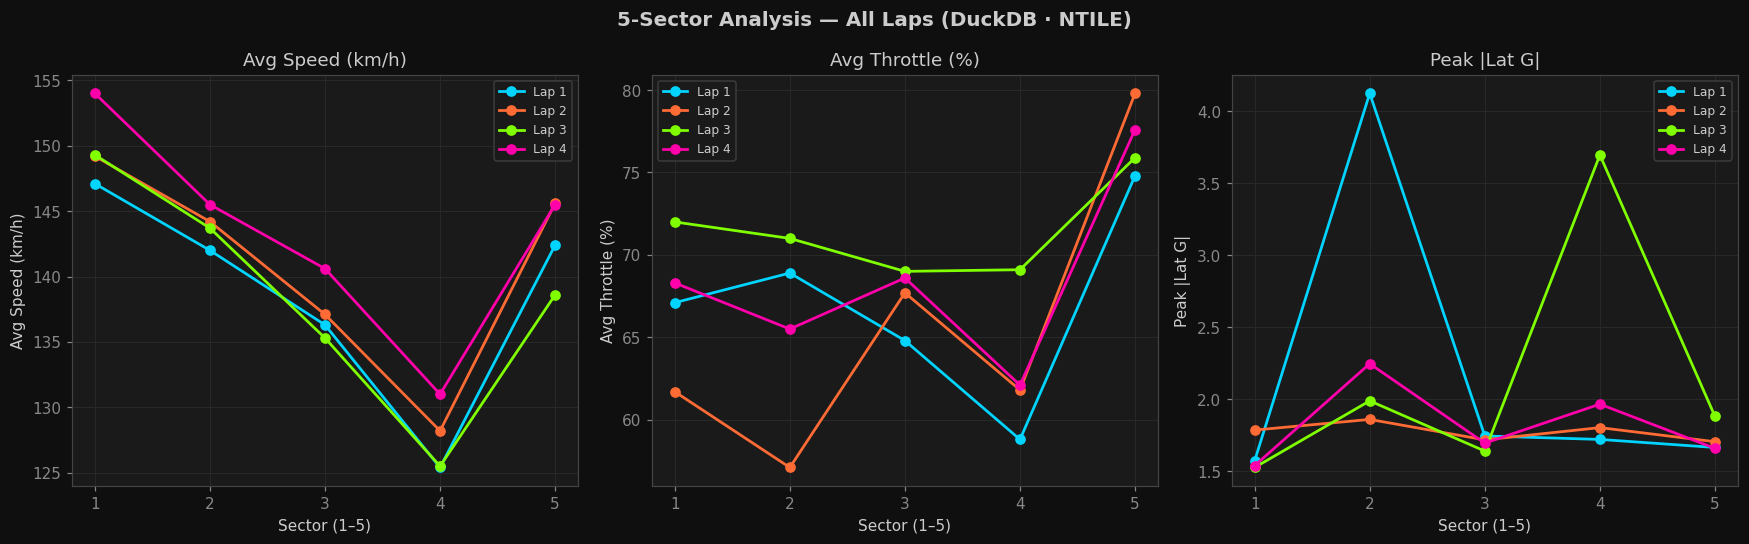

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('5-Sector Analysis — All Laps (DuckDB · NTILE)', fontsize=13, fontweight='bold')

metrics = [('avg_speed_kmh', 'Avg Speed (km/h)'),
           ('avg_throttle_pct', 'Avg Throttle (%)'),
           ('peak_lat_g', 'Peak |Lat G|')]

for ax, (col, ylabel) in zip(axes, metrics):
    for lap in sorted(df_sectors['lap_number'].unique()):
        ld = df_sectors[df_sectors['lap_number'] == lap]
        ax.plot(ld['sector'], ld[col],
                color=LAP_COLORS[lap], marker='o', lw=1.8,
                markersize=6, label=f'Lap {lap}')
    ax.set_xlabel('Sector (1–5)')
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.set_xticks([1,2,3,4,5])
    ax.legend(fontsize=8)
    ax.grid(True)

plt.tight_layout()
plt.savefig('sql_sector_analysis.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 12. [DuckDB] Window Function — Cumulative Fuel & Running Best Lap Time

In [17]:
query = """
WITH lap_totals AS (
    SELECT
        lap_number,
        MAX(current_lap_time)        AS lap_time_s,
        (MAX(fuel) - MIN(fuel))*100  AS fuel_used_pct
    FROM telemetry
    GROUP BY lap_number
)
SELECT
    lap_number,
    ROUND(lap_time_s, 3)                                           AS lap_time_s,
    ROUND(fuel_used_pct, 4)                                        AS fuel_used_pct,
    ROUND(SUM(fuel_used_pct) OVER
          (ORDER BY lap_number ROWS UNBOUNDED PRECEDING), 4)       AS cumulative_fuel_pct,
    ROUND(MIN(lap_time_s) OVER
          (ORDER BY lap_number ROWS UNBOUNDED PRECEDING), 3)       AS running_best_s,
    ROUND(lap_time_s - MIN(lap_time_s) OVER
          (ORDER BY lap_number ROWS UNBOUNDED PRECEDING), 3)       AS gap_to_running_best_s,
    ROUND(AVG(lap_time_s) OVER
          (ORDER BY lap_number ROWS BETWEEN 1 PRECEDING AND 1 FOLLOWING), 3) AS moving_avg_3laps_s
FROM lap_totals
ORDER BY lap_number
"""

df_cum = duck.execute(query).df()
print(df_cum.to_string(index=False))

 lap_number  lap_time_s  fuel_used_pct  cumulative_fuel_pct  running_best_s  gap_to_running_best_s  moving_avg_3laps_s
          1     158.154         7.2031               7.2031         158.154                  0.000             156.926
          2     155.698         6.9078              14.1109         155.698                  0.000             157.561
          3     158.830         7.4882              21.5991         155.698                  3.132             155.880
          4     153.113         7.3192              28.9184         153.113                  0.000             155.972


## 13. [DuckDB] Understeer Heatmap by Section × Lap

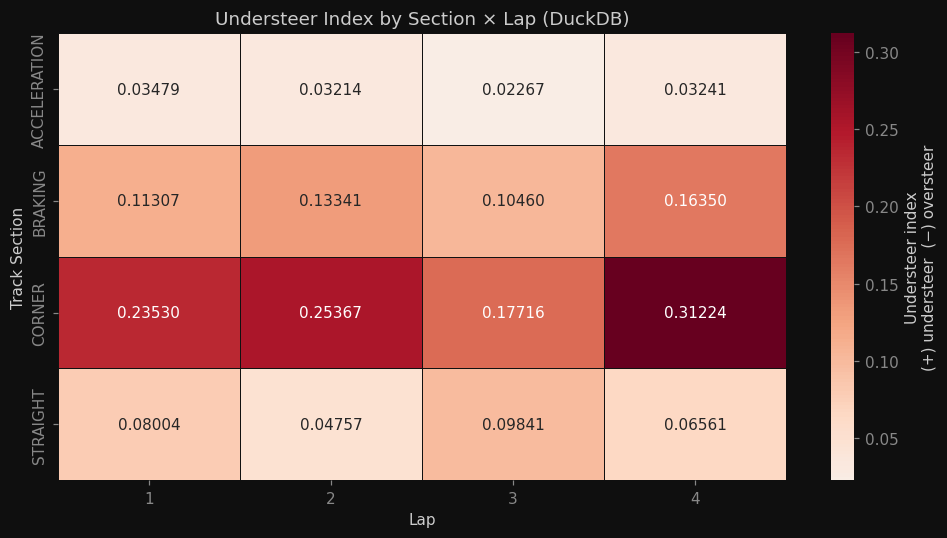

In [18]:
query = """
SELECT
    lap_number,
    track_section,
    ROUND(AVG(understeer_index), 5)      AS avg_understeer,
    ROUND(STDDEV(understeer_index), 5)   AS std_understeer,
    ROUND(AVG(combined_slip_avg), 5)     AS avg_slip,
    COUNT(*)                             AS samples
FROM telemetry
GROUP BY lap_number, track_section
ORDER BY lap_number, track_section
"""

df_us = duck.execute(query).df()

pivot_us = df_us.pivot(index='track_section', columns='lap_number', values='avg_understeer')

fig, ax = plt.subplots(figsize=(9, 5))
import seaborn as sns
sns.heatmap(
    pivot_us, annot=True, fmt='.5f', cmap='RdBu_r', center=0,
    linewidths=0.5, linecolor='#111111',
    cbar_kws={'label': 'Understeer index\n(+) understeer  (−) oversteer'},
    ax=ax
)
ax.set_title('Understeer Index by Section × Lap (DuckDB)', fontsize=12)
ax.set_xlabel('Lap')
ax.set_ylabel('Track Section')
plt.tight_layout()
plt.savefig('sql_understeer_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 14. [DuckDB] Best Sector per Lap — Mini Qualifying Analysis

In [19]:
query = """
WITH sectored AS (
    SELECT
        lap_number,
        NTILE(3) OVER (PARTITION BY lap_number ORDER BY lap_dist_pct) AS sector,
        current_lap_time
    FROM telemetry
),
sector_times AS (
    SELECT
        lap_number,
        sector,
        MAX(current_lap_time) - MIN(current_lap_time) AS sector_time_s
    FROM sectored
    GROUP BY lap_number, sector
),
best_sectors AS (
    SELECT
        sector,
        MIN(sector_time_s)   AS best_sector_time_s,
        ARG_MIN(lap_number, sector_time_s) AS best_lap
    FROM sector_times
    GROUP BY sector
)
SELECT
    st.sector,
    st.lap_number,
    ROUND(st.sector_time_s, 3)                AS sector_time_s,
    ROUND(bs.best_sector_time_s, 3)           AS best_sector_time_s,
    bs.best_lap,
    ROUND(st.sector_time_s
          - bs.best_sector_time_s, 3)         AS gap_to_best_s,
    RANK() OVER (PARTITION BY st.sector
                 ORDER BY st.sector_time_s)   AS sector_rank
FROM sector_times st
JOIN best_sectors bs ON bs.sector = st.sector
ORDER BY st.sector, st.lap_number
"""

df_best_sectors = duck.execute(query).df()
print('Sector times with gap to best (DuckDB):')
print(df_best_sectors.to_string(index=False))

Sector times with gap to best (DuckDB):
 sector  lap_number  sector_time_s  best_sector_time_s  best_lap  gap_to_best_s  sector_rank
      1           1         52.710              51.026         4          1.683            3
      1           2         51.893              51.026         4          0.867            2
      1           3         52.943              51.026         4          1.917            4
      1           4         51.026              51.026         4          0.000            1
      2           1         52.718              51.035         4          1.683            3
      2           2         51.885              51.035         4          0.850            2
      2           3         52.935              51.035         4          1.900            4
      2           4         51.035              51.035         4          0.000            1
      3           1         52.709              51.035         4          1.675            3
      3           2         51

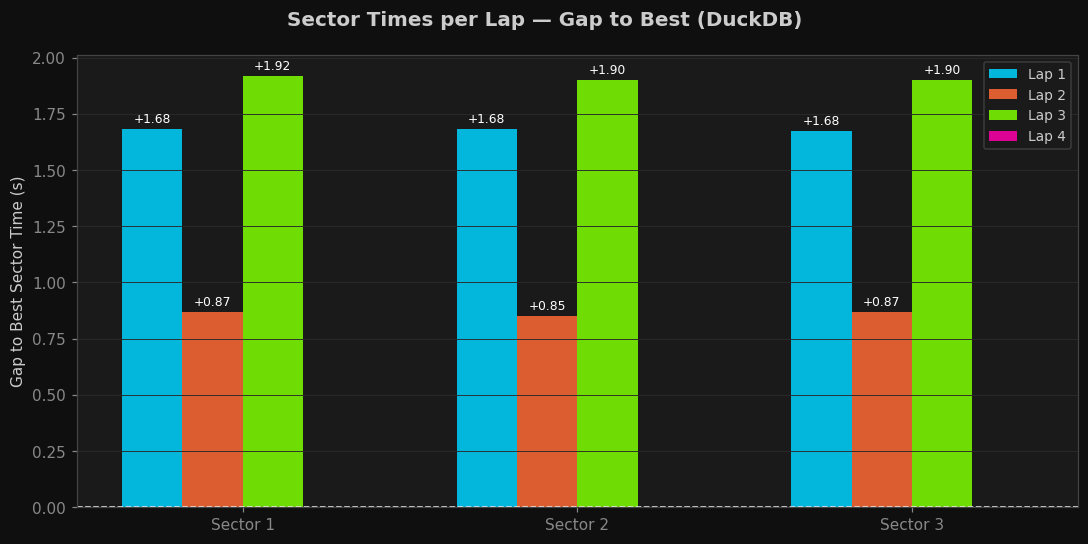

In [20]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Sector Times per Lap — Gap to Best (DuckDB)', fontsize=13, fontweight='bold')

sectors = sorted(df_best_sectors['sector'].unique())
x = np.arange(len(sectors))
w = 0.18
laps_order = sorted(df_best_sectors['lap_number'].unique())

for i, lap in enumerate(laps_order):
    lap_data = df_best_sectors[df_best_sectors['lap_number'] == lap]
    gaps = [lap_data[lap_data['sector'] == s]['gap_to_best_s'].values[0]
            if s in lap_data['sector'].values else np.nan for s in sectors]
    bars = ax.bar(x + i * w, gaps, w, color=LAP_COLORS[lap],
                  alpha=0.85, label=f'Lap {lap}')
    for bar, gap in zip(bars, gaps):
        if gap > 0:
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.03,
                    f'+{gap:.2f}', ha='center', fontsize=8, color='white')

ax.set_xticks(x + w * 1.5)
ax.set_xticklabels([f'Sector {s}' for s in sectors])
ax.set_ylabel('Gap to Best Sector Time (s)')
ax.axhline(0, color='white', lw=1, linestyle='--')
ax.legend(fontsize=9)
ax.grid(True, axis='y')

plt.tight_layout()
plt.savefig('sql_best_sectors.png', dpi=150, bbox_inches='tight', facecolor='#0f0f0f')
plt.show()

## 15. Cleanup

In [21]:
conn.close()
duck.close()
print('Connections closed.')

import os
db_size = os.path.getsize(DB_PATH) / 1024
print(f'SQLite DB size: {db_size:.0f} KB')

Connections closed.
SQLite DB size: 25304 KB


## Summary

### SQLite queries
| # | Query | Technique |
|---|---|---|
| 3 | Lap performance summary | `GROUP BY`, aggregate functions |
| 4 | Track section distribution | `SUM() OVER ()` (scalar window) |
| 5 | Corner ranking & difficulty | Multi-table join, derived score |
| 6 | Safety events map | `CASE WHEN`, spatial filter |
| 7 | Tire temp & fuel per lap | `MIN/MAX/AVG`, arithmetic |

### DuckDB queries
| # | Query | Technique |
|---|---|---|
| 9 | Lap ranking | `RANK()`, `MIN() OVER ()`, `AVG() OVER ()` |
| 10 | Speed delta | `LAG()`, `LEAD()` with partition |
| 11 | Sector breakdown | `NTILE(5)`, `PERCENTILE_CONT()` |
| 12 | Cumulative fuel & running best | `SUM() OVER ROWS UNBOUNDED PRECEDING`, `MIN() OVER` |
| 13 | Understeer heatmap | `STDDEV()`, `GROUP BY` two dimensions |
| 14 | Best sector / qualifying | `ARG_MIN()`, `RANK()`, CTE chain, `JOIN` |

### Output files
- `telemetry.db` — SQLite database (3 tables)
- `queries.sql` — all queries in pure SQL (DuckDB dialect)
- 6 PNG charts saved to project folder